Evaluating: 100%|██████████| 121/121 [00:08<00:00, 14.72it/s]


Epoch 1/10  TrainLoss: -24867.7921  ValAcc: 0.3685  ValF1: 0.0299


Evaluating: 100%|██████████| 121/121 [00:08<00:00, 14.25it/s]


Epoch 2/10  TrainLoss: -89684.6559  ValAcc: 0.3567  ValF1: 0.0292


Evaluating: 100%|██████████| 121/121 [00:08<00:00, 14.91it/s]


...

Epoch 8/10  TrainLoss: -482069.5387  ValAcc: 0.3567  ValF1: 0.0292


Evaluating: 100%|██████████| 121/121 [00:09<00:00, 12.41it/s]


Epoch 9/10  TrainLoss: -549129.3962  ValAcc: 0.3567  ValF1: 0.0292


Evaluating: 100%|██████████| 121/121 [00:09<00:00, 12.56it/s]


Epoch 10/10  TrainLoss: -612009.6623  ValAcc: 0.3685  ValF1: 0.0299


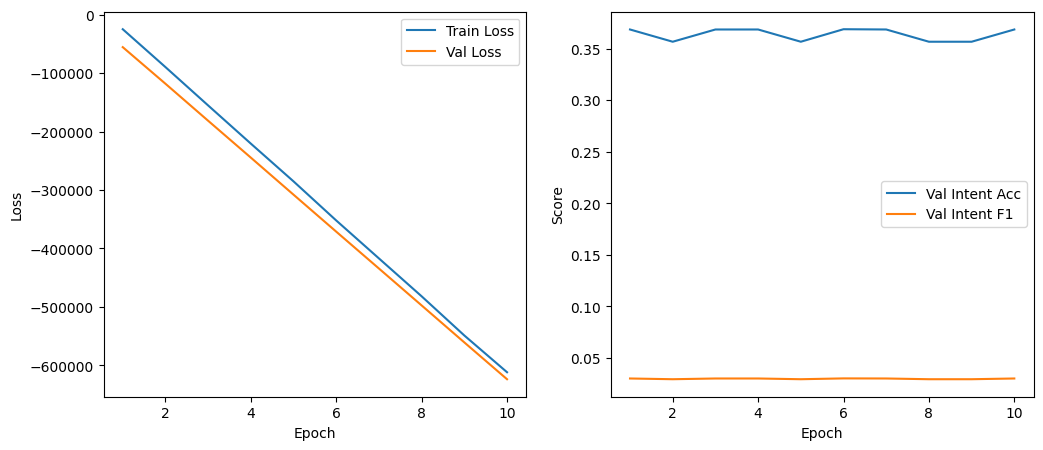

Evaluating: 100%|██████████| 128/128 [00:09<00:00, 14.13it/s]


Test Results - Intent Acc: 0.3534, Intent F1: 0.0290


In [2]:
import os
import re
import json
import random
from typing import List, Dict, Tuple
from collections import Counter
import chardet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# %%
# Cell 2 — TranscriptPreprocessor (same as in model 1; paste your version or import from file)
class TranscriptPreprocessor:
    def __init__(self, transcripts_dir: str, processed_dir: str):
        self.transcripts_dir = transcripts_dir
        self.processed_dir = processed_dir
        self.intents = set()
        self.slot_types = set()
        self.medical_keywords = {
            'SYMPTOM': ['pain', 'cough', 'breathless', 'itching', 'nausea', 'vomiting', 'fever',
                        'headache', 'dizziness', 'fatigue', 'swelling', 'rash', 'discharge',
                        'bleeding', 'numbness', 'tingling', 'weakness', 'stiffness'],
            'LOCATION': ['chest', 'abdomen', 'back', 'head', 'neck', 'arm', 'leg', 'knee',
                         'shoulder', 'hip', 'ankle', 'wrist', 'upper', 'lower', 'left', 'right'],
            'DURATION': ['days', 'weeks', 'months', 'years', 'hours', 'minutes', 'ago',
                         'since', 'yesterday', 'morning', 'evening', 'night', 'recently'],
            'SEVERITY': ['severe', 'mild', 'moderate', 'intense', 'slight', 'terrible',
                         'bad', 'worse', 'better', 'improved'],
            'PROGRESSION': ['getting worse', 'improving', 'constant', 'intermittent',
                            'comes and goes', 'fluctuates', 'stable'],
            'MEDICATION': ['ibuprofen', 'paracetamol', 'aspirin', 'antacid', 'antibiotic',
                           'inhaler', 'cream', 'ointment', 'tablet', 'pill'],
            'HISTORY': ['diabetes', 'hypertension', 'asthma', 'allergy', 'surgery',
                        'family history', 'previous', 'diagnosed']
        }
        os.makedirs(processed_dir, exist_ok=True)

    def load_transcripts(self) -> List[Dict]:
        transcripts = []
        for filename in os.listdir(self.transcripts_dir):
            if filename.endswith('.txt'):
                filepath = os.path.join(self.transcripts_dir, filename)
                category = filename[:3]
                transcript_id = filename[:-4]
                with open(filepath, 'rb') as f:
                    encoding = chardet.detect(f.read())['encoding'] or 'utf-8'
                with open(filepath, 'r', encoding=encoding, errors='ignore') as f:
                    content = f.read()
                transcripts.append({'id': transcript_id, 'category': category, 'content': content, 'filepath': filepath})
        return transcripts

    def parse_turns(self, content: str) -> List[Dict]:
        turns = []
        for line in content.strip().split('\n'):
            line = line.strip()
            if not line:
                continue
            if line.startswith('D:'):
                turns.append({'speaker': 'Doctor', 'text': line[2:].strip()})
            elif line.startswith('P:'):
                turns.append({'speaker': 'Patient', 'text': line[2:].strip()})
        return turns

    def normalize_text(self, text: str) -> str:
        return re.sub(r'\s+', ' ', text.lower().strip())

    def tokenize(self, text: str) -> List[str]:
        return re.sub(r'([?.!,;])', r' \1 ', text).split()

    def infer_intent(self, speaker: str, text: str) -> str:
        t = text.lower()
        if speaker == 'Doctor':
            if any(q in t for q in ['what', 'when', 'where', 'how', 'which', 'who']):
                if 'symptom' in t or 'feel' in t or 'problem' in t:
                    return 'Ask_Symptom'
                elif any(word in t for word in ['long', 'when', 'start', 'began']):
                    return 'Ask_Duration'
                elif 'where' in t or 'location' in t:
                    return 'Ask_Location'
                elif any(word in t for word in ['severe', 'bad', 'intense']):
                    return 'Ask_Severity'
                elif 'medication' in t or 'medicine' in t or 'taking' in t:
                    return 'Ask_Medication'
                elif 'history' in t or 'before' in t or 'previous' in t:
                    return 'Ask_History'
                else:
                    return 'Ask_General'
            elif any(word in t for word in ['test', 'examine', 'check']):
                return 'Propose_Examination'
            elif any(word in t for word in ['prescribe', 'recommend', 'suggest']):
                return 'Provide_Treatment'
            return 'Doctor_Other'
        else:
            for slot, keywords in self.medical_keywords.items():
                if any(word in t for word in keywords):
                    return f'Provide_{slot.capitalize()}'
            return 'Patient_Other'

    def extract_slots(self, text: str) -> List[Dict]:
        t = text.lower()
        entities = []
        for slot_type, keywords in self.medical_keywords.items():
            for kw in keywords:
                for match in re.finditer(rf'\b{re.escape(kw)}\w*\b', t):
                    entities.append({'type': slot_type, 'text': match.group(), 'start': match.start(), 'end': match.end()})
        entities.sort(key=lambda x: x['start'])
        non_overlap = []
        for e in entities:
            if not non_overlap or e['start'] >= non_overlap[-1]['end']:
                non_overlap.append(e)
        return non_overlap

    def tokens_to_bio(self, tokens: List[str], text: str, entities: List[Dict]) -> List[str]:
        bio = ['O'] * len(tokens)
        char_to_token = []
        pos = 0
        text_lower = text.lower()
        for i, token in enumerate(tokens):
            start = text_lower.find(token, pos)
            start = start if start != -1 else pos
            end = start + len(token)
            char_to_token.append((start, end, i))
            pos = end
        for e in entities:
            overlap = [i for s, en, i in char_to_token if s < e['end'] and en > e['start']]
            if overlap:
                bio[overlap[0]] = f'B-{e["type"]}'
                for idx in overlap[1:]:
                    bio[idx] = f'I-{e["type"]}'
        return bio

    def process_transcripts(self) -> List[Dict]:
        data = []
        for t in self.load_transcripts():
            for idx, turn in enumerate(self.parse_turns(t['content'])):
                text = turn['text']
                norm_text = self.normalize_text(text)
                tokens = self.tokenize(norm_text)
                intent = self.infer_intent(turn['speaker'], text)
                self.intents.add(intent)
                entities = self.extract_slots(norm_text)
                self.slot_types.update([e['type'] for e in entities])
                bio_tags = self.tokens_to_bio(tokens, norm_text, entities)
                data.append({'transcript_id': t['id'], 'category': t['category'], 'turn_id': idx,
                             'speaker': turn['speaker'], 'original_text': text, 'normalized_text': norm_text,
                             'tokens': tokens, 'intent': intent, 'entities': entities, 'bio_tags': bio_tags})
        return data

    def create_splits(self, data: List[Dict], train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42) -> Tuple[List[Dict], List[Dict], List[Dict]]:
        ids = list({item['transcript_id'] for item in data})
        random.seed(seed)
        random.shuffle(ids)
        n_train = int(len(ids) * train_ratio)
        n_val = int(len(ids) * val_ratio)
        train_ids, val_ids, test_ids = set(ids[:n_train]), set(ids[n_train:n_train+n_val]), set(ids[n_train+n_val:])
        train_data = [x for x in data if x['transcript_id'] in train_ids]
        val_data = [x for x in data if x['transcript_id'] in val_ids]
        test_data = [x for x in data if x['transcript_id'] in test_ids]
        return train_data, val_data, test_data

    def save_processed_data(self, train_data: List[Dict], val_data: List[Dict], test_data: List[Dict]):
        for name, d in zip(['train', 'val', 'test'], [train_data, val_data, test_data]):
            with open(os.path.join(self.processed_dir, f'{name}.json'), 'w') as f:
                json.dump(d, f, indent=2)
        metadata = {'intents': sorted(list(self.intents)),
                    'slots': ['O'] + [f'{p}-{s}' for s in sorted(self.slot_types) for p in ['B', 'I']],
                    'num_intents': len(self.intents),
                    'num_slots': len(self.slot_types)+1,
                    'train_size': len(train_data),
                    'val_size': len(val_data),
                    'test_size': len(test_data)}
        with open(os.path.join(self.processed_dir, 'metadata.json'), 'w') as f:
            json.dump(metadata, f, indent=2)
        return metadata

    def get_statistics(self, data: List[Dict]) -> Dict:
        return {
            'num_utterances': len(data),
            'num_transcripts': len(set([x['transcript_id'] for x in data])),
            'intent_distribution': Counter([x['intent'] for x in data]),
            'category_distribution': Counter([x['category'] for x in data]),
            'speaker_distribution': Counter([x['speaker'] for x in data]),
            'avg_tokens_per_utterance': sum(len(x['tokens']) for x in data)/len(data) if data else 0,
            'slot_type_counts': Counter([e['type'] for x in data for e in x['entities']])
        }

# %%
# Cell 3 — Dataset, collate, and vocab builders
class SLUDataset(Dataset):
    def __init__(self, data: List[Dict], vocab: Dict, intent2id: Dict, slot2id: Dict):
        self.data = data
        self.vocab = vocab
        self.intent2id = intent2id
        self.slot2id = slot2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        token_ids = [self.vocab.get(token, self.vocab['<UNK>']) for token in item['tokens']]
        intent_id = self.intent2id[item['intent']]
        slot_ids = [self.slot2id[tag] for tag in item['bio_tags']]
        return {
            'token_ids': torch.tensor(token_ids, dtype=torch.long),
            'intent_id': torch.tensor(intent_id, dtype=torch.long),
            'slot_ids': torch.tensor(slot_ids, dtype=torch.long),
            'length': len(token_ids)
        }


def collate_fn(batch):
    token_ids = [item['token_ids'] for item in batch]
    slot_ids = [item['slot_ids'] for item in batch]
    lengths = [item['length'] for item in batch]
    intent_ids = torch.stack([item['intent_id'] for item in batch])

    max_len = max(lengths)
    padded_tokens = torch.zeros(len(batch), max_len, dtype=torch.long)
    padded_slots = torch.zeros(len(batch), max_len, dtype=torch.long)

    for i, (tokens, slots, length) in enumerate(zip(token_ids, slot_ids, lengths)):
        padded_tokens[i, :length] = tokens
        padded_slots[i, :length] = slots

    return {
        'token_ids': padded_tokens,
        'slot_ids': padded_slots,
        'intent_ids': intent_ids,
        'lengths': torch.tensor(lengths, dtype=torch.long)
    }


def build_vocab(data: List[Dict], min_freq=2) -> Tuple[Dict, Dict]:
    token_counts = {}
    for item in data:
        for token in item['tokens']:
            token_counts[token] = token_counts.get(token, 0) + 1
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for token, count in token_counts.items():
        if count >= min_freq:
            vocab[token] = len(vocab)
    id2token = {idx: token for token, idx in vocab.items()}
    return vocab, id2token

# %%
# Cell 4 — BiLSTM + Simple CRF model implementation
class SimpleCRF(nn.Module):
    def __init__(self, num_tags: int):
        super(SimpleCRF, self).__init__()
        self.num_tags = num_tags
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))
        self.start_transitions = nn.Parameter(torch.randn(num_tags))
        self.end_transitions = nn.Parameter(torch.randn(num_tags))

    def forward(self, logits: torch.Tensor, tags: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        numerator = self._compute_score(logits, tags, mask)
        denominator = self._compute_normalizer(logits, mask)
        return torch.sum(denominator - numerator)

    def _compute_score(self, logits, tags, mask):
        batch_size, seq_len, _ = logits.shape
        score = self.start_transitions[tags[:, 0]] + logits[:, 0, :].gather(1, tags[:, 0].unsqueeze(1)).squeeze(1)
        for i in range(1, seq_len):
            score += self.transitions[tags[:, i - 1], tags[:, i]]
            score += logits[:, i, :].gather(1, tags[:, i].unsqueeze(1)).squeeze(1)
            score *= mask[:, i]
        seq_ends = mask.long().sum(dim=1) - 1
        score += self.end_transitions[tags[torch.arange(batch_size), seq_ends]]
        return score

    def _compute_normalizer(self, logits, mask):
        batch_size, seq_len, num_tags = logits.shape
        log_alpha = self.start_transitions + logits[:, 0]
        for t in range(1, seq_len):
            log_alpha_exp = log_alpha.unsqueeze(2) + self.transitions.unsqueeze(0)
            log_alpha = torch.logsumexp(log_alpha_exp + logits[:, t].unsqueeze(1), dim=1)
            log_alpha = torch.where(mask[:, t].unsqueeze(1), log_alpha, log_alpha)
        log_alpha += self.end_transitions
        return torch.logsumexp(log_alpha, dim=1)

    def decode(self, logits, mask):
        batch_size, seq_len, num_tags = logits.shape
        viterbi = self.start_transitions + logits[:, 0]
        backpointers = []
        for t in range(1, seq_len):
            viterbi_exp = viterbi.unsqueeze(2) + self.transitions.unsqueeze(0)
            viterbi_new, bp = torch.max(viterbi_exp + logits[:, t].unsqueeze(1), dim=1)
            backpointers.append(bp)
            viterbi = torch.where(mask[:, t].unsqueeze(1), viterbi_new, viterbi)
        seq_ends = mask.long().sum(dim=1) - 1
        best_tags_list = []
        for b in range(batch_size):
            seq_len_b = int(seq_ends[b] + 1)
            best_tag = torch.argmax(viterbi[b]).item()
            best_tags = [best_tag]
            for bp_t in reversed(backpointers[:seq_len_b - 1]):
                best_tag = bp_t[b, best_tag].item()
                best_tags.append(best_tag)
            best_tags.reverse()
            best_tags_list.append(best_tags)
        return best_tags_list

class BiLSTMCRF(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_intents, num_slots, dropout=0.3, pretrained_embeddings=None):
        super(BiLSTMCRF, self).__init__()
        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(pretrained_embeddings), freeze=False)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim // 2, num_layers=2, bidirectional=True,
            batch_first=True, dropout=dropout if embedding_dim > 1 else 0
        )
        self.slot_projection = nn.Linear(hidden_dim, num_slots)
        self.crf = SimpleCRF(num_slots)
        self.intent_projection = nn.Linear(hidden_dim, num_intents)

    def forward(self, token_ids, lengths, slot_ids=None):
        batch_size, seq_len = token_ids.size()
        embeddings = self.dropout(self.embedding(token_ids))
        packed = nn.utils.rnn.pack_padded_sequence(embeddings, lengths.cpu(), batch_first=True, enforce_sorted=False)
        lstm_out, (hidden, _) = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        lstm_out = self.dropout(lstm_out)
        slot_logits = self.slot_projection(lstm_out)
        mask = torch.arange(seq_len).expand(batch_size, seq_len).to(token_ids.device) < lengths.unsqueeze(1)
        slot_loss = self.crf(slot_logits, slot_ids, mask) if slot_ids is not None else None
        predicted_slots = self.crf.decode(slot_logits, mask)
        hidden_concat = torch.cat([hidden[-2], hidden[-1]], dim=1)
        intent_logits = self.intent_projection(hidden_concat)
        return slot_loss, predicted_slots, intent_logits

# %%
# Cell 5 — Training & evaluation utilities
def train_epoch(model, dataloader, optimizer, intent_criterion, device):
    model.train()
    total_slot_loss, total_intent_loss = 0, 0
    for batch in tqdm(dataloader, desc="Training"):
        token_ids = batch['token_ids'].to(device)
        slot_ids = batch['slot_ids'].to(device)
        intent_ids = batch['intent_ids'].to(device)
        lengths = batch['lengths'].to(device)
        optimizer.zero_grad()
        slot_loss, _, intent_logits = model(token_ids, lengths, slot_ids)
        intent_loss = intent_criterion(intent_logits, intent_ids)
        loss = slot_loss + intent_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_slot_loss += slot_loss.item()
        total_intent_loss += intent_loss.item()
    return total_slot_loss / len(dataloader), total_intent_loss / len(dataloader)


def evaluate(model, dataloader, intent_criterion, device, id2intent, id2slot):
    model.eval()
    total_slot_loss, total_intent_loss = 0, 0
    all_intent_preds, all_intent_trues = [], []
    all_slot_preds, all_slot_trues = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            token_ids = batch['token_ids'].to(device)
            slot_ids = batch['slot_ids'].to(device)
            intent_ids = batch['intent_ids'].to(device)
            lengths = batch['lengths'].to(device)
            slot_loss, predicted_slots, intent_logits = model(token_ids, lengths, slot_ids)
            intent_loss = intent_criterion(intent_logits, intent_ids)
            total_slot_loss += slot_loss.item()
            total_intent_loss += intent_loss.item()
            all_intent_preds.extend(torch.argmax(intent_logits, dim=1).cpu().numpy())
            all_intent_trues.extend(intent_ids.cpu().numpy())
            for i, length in enumerate(lengths):
                all_slot_preds.append([id2slot[s] for s in predicted_slots[i][:length]])
                all_slot_trues.append([id2slot[int(s)] for s in slot_ids[i][:length].cpu().numpy()])
    intent_acc = accuracy_score(all_intent_trues, all_intent_preds)
    intent_f1 = f1_score(all_intent_trues, all_intent_preds, average='macro', zero_division=0)
    return total_slot_loss / len(dataloader), total_intent_loss / len(dataloader), intent_acc, intent_f1, all_slot_preds, all_slot_trues


def plot_metrics(history):
    epochs = list(range(1, len(history['train_loss'])+1))
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, history['val_acc'], label='Val Intent Acc')
    plt.plot(epochs, history['val_f1'], label='Val Intent F1')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.show()

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    with open('data/processed/train.json', 'r') as f: train_data = json.load(f)
    with open('data/processed/val.json', 'r') as f: val_data = json.load(f)
    with open('data/processed/test.json', 'r') as f: test_data = json.load(f)
    with open('data/processed/metadata.json', 'r') as f: metadata = json.load(f)

    vocab, id2token = build_vocab(train_data)
    intent2id = {intent: idx for idx, intent in enumerate(metadata['intents'])}
    id2intent = {idx: intent for intent, idx in intent2id.items()}
    slot2id = {slot: idx for idx, slot in enumerate(metadata['slots'])}
    id2slot = {idx: slot for slot, idx in slot2id.items()}

    train_loader = DataLoader(SLUDataset(train_data, vocab, intent2id, slot2id),
                              batch_size=32, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(SLUDataset(val_data, vocab, intent2id, slot2id),
                            batch_size=32, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(SLUDataset(test_data, vocab, intent2id, slot2id),
                             batch_size=32, shuffle=False, collate_fn=collate_fn)

    model = BiLSTMCRF(len(vocab), embedding_dim=300, hidden_dim=256,
                      num_intents=len(intent2id), num_slots=len(slot2id),
                      dropout=0.3).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    intent_criterion = nn.CrossEntropyLoss()
    best_val_acc = 0
    num_epochs = 10
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(num_epochs):
        train_slot_loss, train_intent_loss = train_epoch(model, train_loader, optimizer, intent_criterion, device)
        val_slot_loss, val_intent_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, intent_criterion, device, id2intent, id2slot)
        history['train_loss'].append(train_slot_loss + train_intent_loss)
        history['val_loss'].append(val_slot_loss + val_intent_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        print(f"Epoch {epoch+1}/{num_epochs}  TrainLoss: {history['train_loss'][-1]:.4f}  ValAcc: {val_acc:.4f}  ValF1: {val_f1:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'data/processed/bilstm_crf_model.pt')

    plot_metrics(history)
    model.load_state_dict(torch.load('data/processed/bilstm_crf_model.pt', map_location=device))
    test_slot_loss, test_intent_loss, test_acc, test_f1, slot_preds, slot_trues = evaluate(model, test_loader, intent_criterion, device, id2intent, id2slot)
    print(f"Test Results - Intent Acc: {test_acc:.4f}, Intent F1: {test_f1:.4f}")

if __name__ == '__main__':
    main()
